In [1]:
suppressPackageStartupMessages({
    library(ArchR) 
    library(data.table)
    library(purrr)
    library(parallel)
    library(dplyr)
    library(ggpubr)
    library(Matrix)
    library(SingleCellExperiment)
    library(Seurat)
    library(reshape2)
    library(scater)
    library(viridis)
})

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
# I/O
io = list()
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2'
io$output.directory <- file.path(io$basedir,"ArchR")
io$plot.dir = file.path(io$output.directory,'Plots')
io$outdir =  file.path(io$output.directory,"Loops")
dir.create(io$outdir, showWarnings = FALSE)


setwd(io$output.directory)

In [3]:
io$archR.directory = file.path(io$output.directory, 'Project/')
ArchRProject.filt = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [4]:
ArchRProject.filt <- addCoAccessibility(
    ArchRProj = ArchRProject.filt,
  #  reducedDims = "IterativeLSI_Harmony"
    reducedDims = "IterativeLSI"
)

ArchR logging to : ArchRLogs/ArchR-addCoAccessibility-1a2464699b85c-Date-2021-12-12_Time-19-48-10.log
If there is an issue, please report to github with logFile!

2021-12-12 19:48:11 : Computing KNN, 0.018 mins elapsed.

2021-12-12 19:48:12 : Identifying Non-Overlapping KNN pairs, 0.035 mins elapsed.

2021-12-12 19:48:14 : Identified 500 Groupings!, 0.07 mins elapsed.

2021-12-12 19:48:39 : Computing Co-Accessibility chr1 (1 of 22), 0.473 mins elapsed.

2021-12-12 19:49:16 : Computing Co-Accessibility chr2 (2 of 22), 1.102 mins elapsed.

2021-12-12 19:49:46 : Computing Co-Accessibility chr3 (3 of 22), 1.6 mins elapsed.

2021-12-12 19:50:11 : Computing Co-Accessibility chr4 (4 of 22), 2.011 mins elapsed.

2021-12-12 19:50:30 : Computing Co-Accessibility chr5 (5 of 22), 2.332 mins elapsed.

2021-12-12 19:50:43 : Computing Co-Accessibility chr6 (6 of 22), 2.54 mins elapsed.

2021-12-12 19:50:51 : Computing Co-Accessibility chr7 (7 of 22), 2.676 mins elapsed.

2021-12-12 19:51:17 : Computi

In [5]:
cA <- getCoAccessibility(
    ArchRProj = ArchRProject.filt,
    corCutOff = 0.5,
    resolution = 1,
    returnLoops = TRUE
)

saveRDS(cA, file.path(io$outdir, 'coAccessibility.rds'))

In [6]:
ArchRProject.filt <- addPeak2GeneLinks(
    ArchRProj = ArchRProject.filt,
   # reducedDims = "IterativeLSI_Harmony",
    reducedDims = "IterativeLSI",
    useMatrix = "GeneIntegrationMatrix"
)

ArchR logging to : ArchRLogs/ArchR-addPeak2GeneLinks-1a2463ad72f33-Date-2021-12-12_Time-19-56-04.log
If there is an issue, please report to github with logFile!

2021-12-12 19:56:04 : Getting Available Matrices, 0.005 mins elapsed.

2021-12-12 19:56:05 : Filtered Low Prediction Score Cells (3974 of 33115, 0.12), 0.004 mins elapsed.

2021-12-12 19:56:05 : Computing KNN, 0.01 mins elapsed.

2021-12-12 19:56:06 : Identifying Non-Overlapping KNN pairs, 0.019 mins elapsed.

2021-12-12 19:56:08 : Identified 500 Groupings!, 0.052 mins elapsed.

2021-12-12 19:56:08 : Getting Group RNA Matrix, 0.054 mins elapsed.

2021-12-12 19:58:07 : Getting Group ATAC Matrix, 2.037 mins elapsed.

2021-12-12 20:02:55 : Normalizing Group Matrices, 6.836 mins elapsed.

2021-12-12 20:03:10 : Finding Peak Gene Pairings, 7.084 mins elapsed.

2021-12-12 20:03:11 : Computing Correlations, 7.105 mins elapsed.

2021-12-12 20:03:33 : Completed Peak2Gene Correlations!, 7.471 mins elapsed.

ArchR logging successful to : 

In [7]:
p2g <- getPeak2GeneLinks(
    ArchRProj = ArchRProject.filt,
    corCutOff = 0.45,
    resolution = 1,
    returnLoops = TRUE
)

saveRDS(p2g, file.path(io$outdir, 'Peak2GeneLinks.rds'))

In [8]:
saveArchRProject(ArchRProj = ArchRProject.filt)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(25): Clusters sample ... ReadsInPeaks FRIP
numberOfCells(1): 33115
medianTSS(1): 3.407
medianFrags(1): 31914

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id             symbol
         <Rle>         <IRanges>  <Rle> |        <character>        <character>
  [1]    chr14 14476103-14480746      - | ENSOCUG00000000451 ENSOCUG00000000451
  -------
  seqinfo: 22 sequences from an unspecified genome


Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”


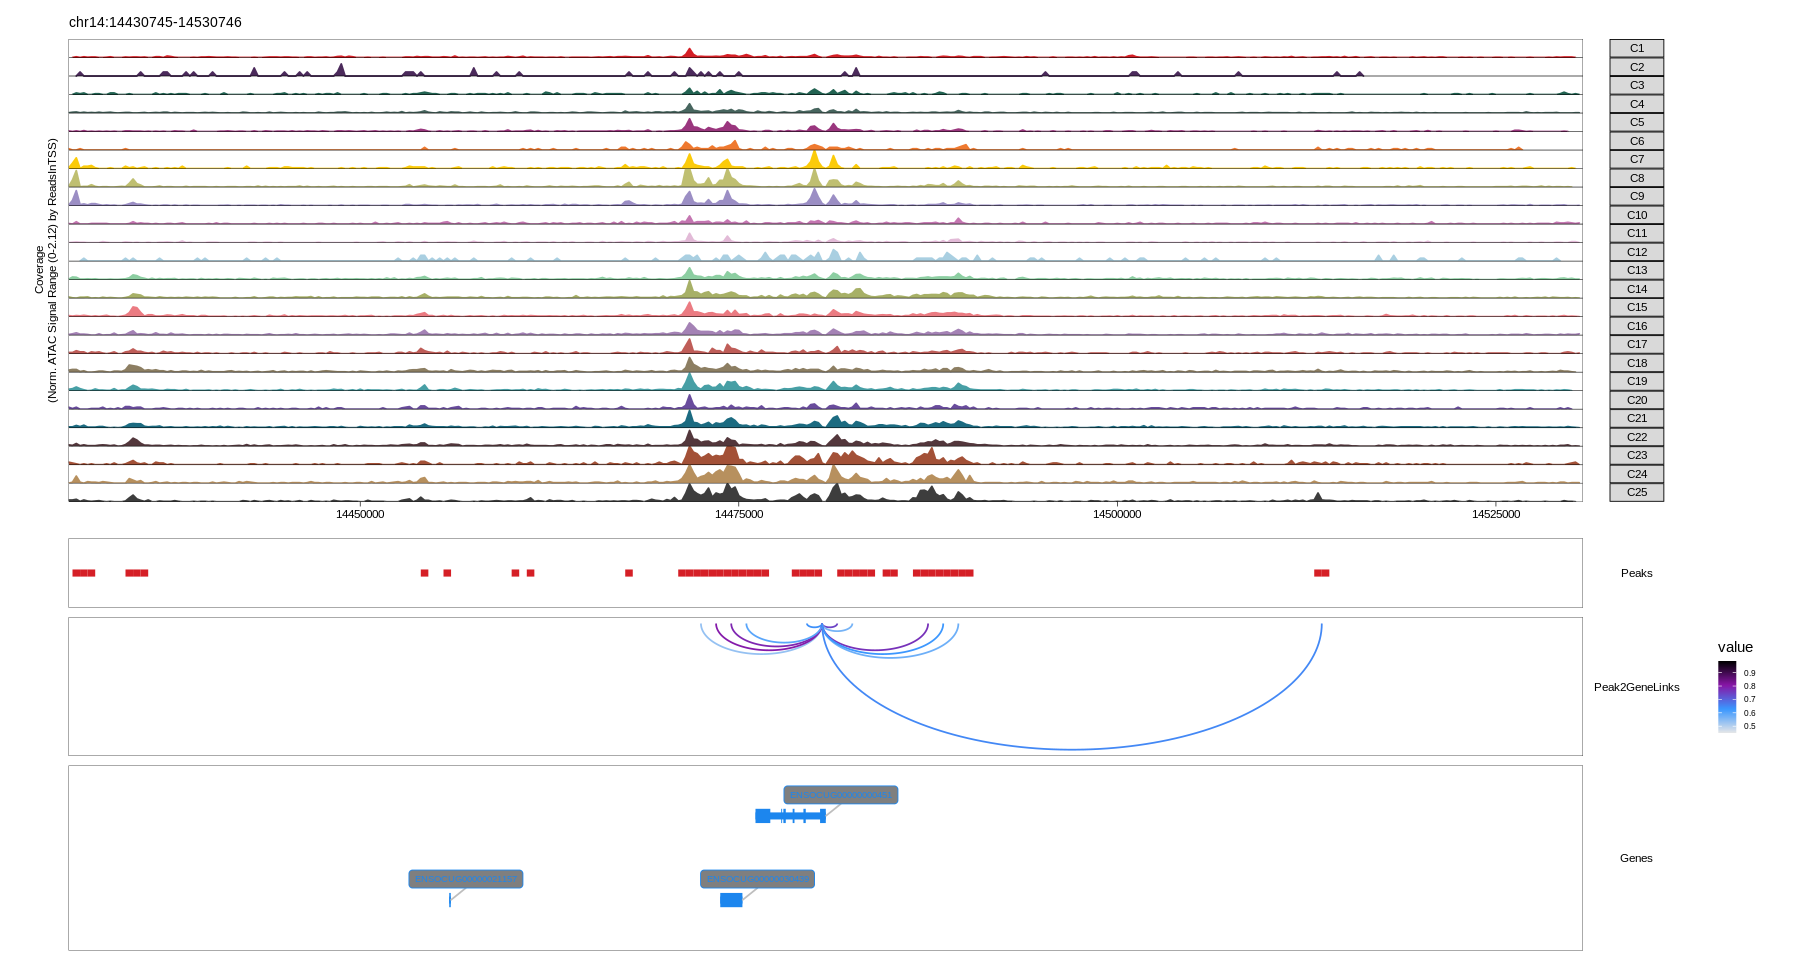

In [9]:
markerGenes = 'ENSOCUG00000000451'

p <- suppressMessages( plotBrowserTrack(
    ArchRProj = ArchRProject.filt, 
    groupBy = "Clusters", 
    geneSymbol = markerGenes, 
    upstream = 50000,
    downstream = 50000,
    loops = getPeak2GeneLinks(ArchRProject.filt, resolution = 1000)
   # loops = getCoAccessibility(ArchRProject.filt, resolution = 10000)
))

grid::grid.newpage()
grid::grid.draw(p[[1]])

### Identification of Positive TF-Regulators

#### Step 1. Identify Deviant TF Motifs

In [21]:
seGroupMotif <- getGroupSE(ArchRProj = ArchRProject.filt, useMatrix = "MotifMatrix", groupBy = "Clusters")

seZ <- seGroupMotif[rowData(seGroupMotif)$seqnames=="z",] # Get Z-scores
rowData(seZ)$maxDelta <- lapply(seq_len(ncol(seZ)), function(x){ # identify the maximum delta in z-score between all clusters
  rowMaxs(assay(seZ) - assay(seZ)[,x])
}) %>% Reduce("cbind", .) %>% rowMaxs

ArchR logging to : ArchRLogs/ArchR-getGroupSE-27b3523391c88-Date-2021-12-06_Time-09-27-46.log
If there is an issue, please report to github with logFile!

Getting Group Matrix

2021-12-06 09:27:47 : Constructing Group Matrix 1 of 2, 0.004 mins elapsed.

2021-12-06 09:27:56 : Finished Group Matrix 1 of 2, 0.154 mins elapsed.

2021-12-06 09:27:56 : Constructing Group Matrix 2 of 2, 0.154 mins elapsed.

2021-12-06 09:28:04 : Finished Group Matrix 2 of 2, 0.293 mins elapsed.

2021-12-06 09:28:04 : Successfully Created Group Matrix, 0.293 mins elapsed.

Normalizing by number of Cells

ArchR logging successful to : ArchRLogs/ArchR-getGroupSE-27b3523391c88-Date-2021-12-06_Time-09-27-46.log



In [22]:
saveRDS(seGroupMotif, file.path(io$outdir, 'seGroupMotif.rds'))

#### Step 2. Identify Correlated TF Motifs and TF Gene Score/Expression

In [53]:
ArchRProject.filt@geneAnnotation$genes$symbol = paste0('test_', ArchRProject.filt@geneAnnotation$genes$symbol)

In [55]:
getFeatures(ArchRProject.filt, "GeneScoreMatrix")

ERROR: Error in getFeatures(ArchRProject.filt, "GeneScoreMatrix") = paste0("test_", : could not find function "getFeatures<-"


In [23]:
corGSM_MM <- correlateMatrices(
    ArchRProj = ArchRProject.filt,
    useMatrix1 = "GeneScoreMatrix",
    useMatrix2 = "MotifMatrix",
    #reducedDims = "IterativeLSI_Harmony"
    reducedDims = "IterativeLSI"
)


ArchR logging to : ArchRLogs/ArchR-correlateMatrices-27b355cd8793d-Date-2021-12-06_Time-09-28-06.log
If there is an issue, please report to github with logFile!

When accessing features from a matrix of class Sparse.Assays.Matrix it requires 1 seqname!
Continuing with first seqname 'z'!
If confused, try getFeatures(ArchRProj, 'MotifMatrix') to list out available seqnames for input!

Matching of useMatrix1 and useMatrix2 resulted in no mappings!



ERROR: Error: 



In [24]:

corGIM_MM <- correlateMatrices(
    ArchRProj = ArchRProject.filt,
    useMatrix1 = "GeneIntegrationMatrix",
    useMatrix2 = "MotifMatrix",
    #reducedDims = "IterativeLSI_Harmony"
    reducedDims = "IterativeLSI"
)

ArchR logging to : ArchRLogs/ArchR-correlateMatrices-27b355ee1d50f-Date-2021-12-06_Time-09-29-27.log
If there is an issue, please report to github with logFile!

When accessing features from a matrix of class Sparse.Assays.Matrix it requires 1 seqname!
Continuing with first seqname 'z'!
If confused, try getFeatures(ArchRProj, 'MotifMatrix') to list out available seqnames for input!

Matching of useMatrix1 and useMatrix2 resulted in no mappings!



ERROR: Error: 



#### Step 3. Add Maximum Delta Deviation to the Correlation Data Frame

In [ ]:
corGSM_MM$maxDelta <- rowData(seZ)[match(corGSM_MM$MotifMatrix_name, rowData(seZ)$name), "maxDelta"]
corGIM_MM$maxDelta <- rowData(seZ)[match(corGIM_MM$MotifMatrix_name, rowData(seZ)$name), "maxDelta"]

#### Step 4. Identify Positive TF Regulators

In [ ]:
corGSM_MM <- corGSM_MM[order(abs(corGSM_MM$cor), decreasing = TRUE), ]
corGSM_MM <- corGSM_MM[which(!duplicated(gsub("\\-.*","",corGSM_MM[,"MotifMatrix_name"]))), ]
corGSM_MM$TFRegulator <- "NO"
corGSM_MM$TFRegulator[which(corGSM_MM$cor > 0.5 & corGSM_MM$padj < 0.01 & corGSM_MM$maxDelta > quantile(corGSM_MM$maxDelta, 0.75))] <- "YES"
sort(corGSM_MM[corGSM_MM$TFRegulator=="YES",1])

In [ ]:
saveRDS(corGSM_MM, file.path(io$outdir, 'corGSM_MM.rds'))

In [ ]:
p <- ggplot(data.frame(corGSM_MM), aes(cor, maxDelta, color = TFRegulator)) +
  geom_point() + 
  theme_ArchR() +
  geom_vline(xintercept = 0, lty = "dashed") + 
  scale_color_manual(values = c("NO"="darkgrey", "YES"="firebrick3")) +
  xlab("Correlation To Gene Score") +
  ylab("Max TF Motif Delta") +
  scale_y_continuous(
    expand = c(0,0), 
    limits = c(0, max(corGSM_MM$maxDelta)*1.05)
  )

p

In [ ]:
corGIM_MM <- corGIM_MM[order(abs(corGIM_MM$cor), decreasing = TRUE), ]
corGIM_MM <- corGIM_MM[which(!duplicated(gsub("\\-.*","",corGIM_MM[,"MotifMatrix_name"]))), ]
corGIM_MM$TFRegulator <- "NO"
corGIM_MM$TFRegulator[which(corGIM_MM$cor > 0.5 & corGIM_MM$padj < 0.01 & corGIM_MM$maxDelta > quantile(corGIM_MM$maxDelta, 0.75))] <- "YES"
sort(corGIM_MM[corGIM_MM$TFRegulator=="YES",1])

In [ ]:
saveRDS(corGIM_MM, file.path(io$outdir, 'corGIM_MM.rds'))

In [ ]:
p <- ggplot(data.frame(corGIM_MM), aes(cor, maxDelta, color = TFRegulator)) +
  geom_point() + 
  theme_ArchR() +
  geom_vline(xintercept = 0, lty = "dashed") + 
  scale_color_manual(values = c("NO"="darkgrey", "YES"="firebrick3")) +
  xlab("Correlation To Gene Expression") +
  ylab("Max TF Motif Delta") +
  scale_y_continuous(
    expand = c(0,0), 
    limits = c(0, max(corGIM_MM$maxDelta)*1.05)
  )

p

In [ ]:
saveArchRProject(ArchRProj = ArchRProject.filt)